In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import ttest_ind
import pingouin as pg
from statsmodels.multivariate.manova import MANOVA
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("results-survey-final-cleaned2.csv", delimiter=";")
df.rename(columns={df.columns[13]: 'group_number'}, inplace=True)

In [3]:
col1 = "What did you find most useful/helpful about the explanation?"
col2 = "What improvements would you suggest?"

# Drop rows where both columns are either NaN or empty string
df = df[~((df[col1].isna() | (df[col1].str.strip() == "")) &
          (df[col2].isna() | (df[col2].str.strip() == "")))]

In [5]:
selected_df = df[[col1, col2]]
selected_df.to_excel("qualitative_responses.xlsx", index=False)

In [6]:

# Function to check for empty/no responses
def count_no_responses(series):
    empty_responses = series.isna().sum()
    no_suggestions = series.str.lower().str.contains('none|n/a|no|nothing', na=False).sum()
    return empty_responses + no_suggestions

# Calculate statistics
stats = {
    'Total_Responses': len(df),
    'No_Answer_Most_Useful': count_no_responses(selected_df[col1]),
    'No_Answer_Improvements': count_no_responses(selected_df[col2]),
    'Average_Length_Most_Useful': selected_df[col1].str.len().mean(),
    'Average_Length_Improvements': selected_df[col2].str.len().mean()
}

# Print statistics
for key, value in stats.items():
    print(f"{key}: {value:.2f}")


Total_Responses: 333.00
No_Answer_Most_Useful: 78.00
No_Answer_Improvements: 125.00
Average_Length_Most_Useful: 142.17
Average_Length_Improvements: 108.04



=== ANALYSIS RESULTS ===

Response Rates:
Total responses: 333
'Most Useful' responses: 333 (100.0%)
'Improvements' responses: 322 (96.7%)

Most Useful Themes:
Bias Identification: 175 mentions (52.6%)
Specific Examples: 68 mentions (20.4%)
Clarity and Simplicity: 74 mentions (22.2%)
Educational Value: 63 mentions (18.9%)
Balanced Perspective: 30 mentions (9.0%)
Detailed Analysis: 15 mentions (4.5%)

Improvements Themes:
More Examples: 9 mentions (2.8%)
Balanced Perspectives: 33 mentions (10.2%)
Clarity Improvements: 8 mentions (2.5%)
Visual Aids: 12 mentions (3.7%)
Factual Support: 48 mentions (14.9%)
Language and Tone: 21 mentions (6.5%)
Actionable Tips: 12 mentions (3.7%)
Formatting: 24 mentions (7.5%)


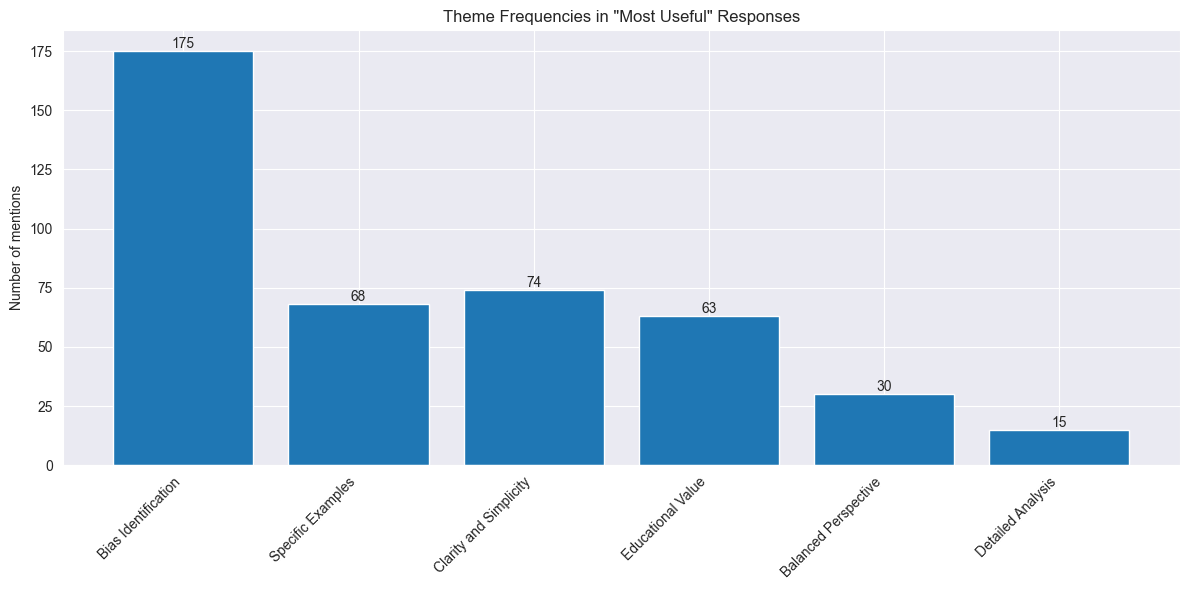

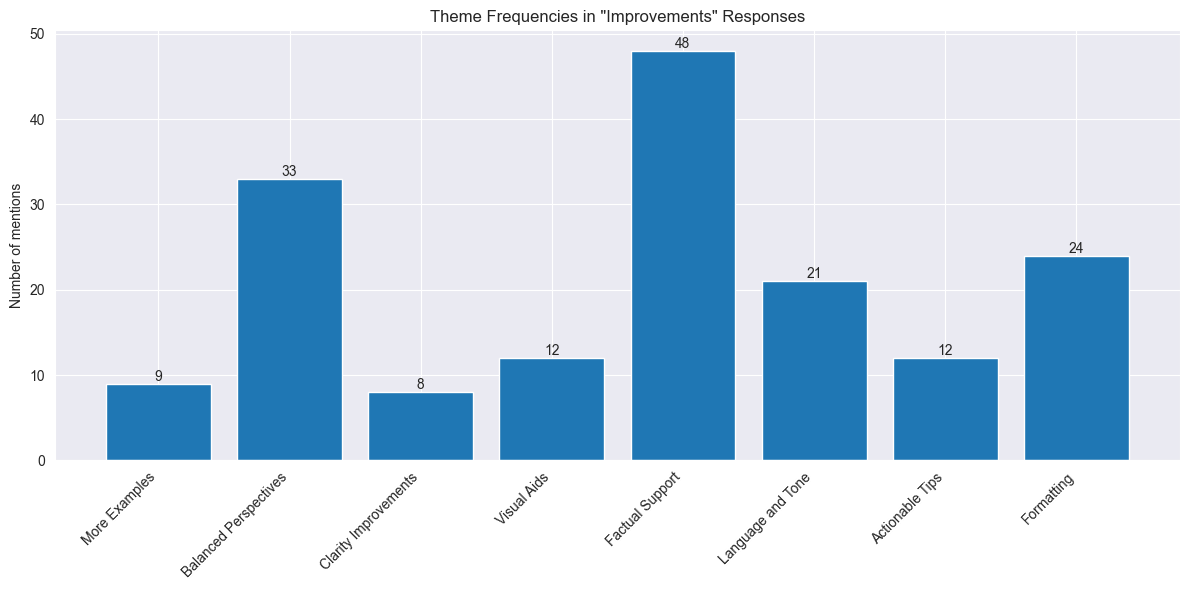

In [9]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import re


# Define themes and their associated keywords for "Most Useful"
most_useful_themes = {
    'Bias Identification': ['bias', 'biased', 'slant', 'perspective', 'leaning', 'subjective'],
    'Specific Examples': ['example', 'specific', 'concrete', 'illustration', 'demonstrate'],
    'Clarity and Simplicity': ['clear', 'simple', 'concise', 'easy to understand', 'straightforward'],
    'Educational Value': ['learn', 'educational', 'informative', 'helpful', 'understand'],
    'Balanced Perspective': ['balanced', 'neutral', 'fair', 'objective', 'both sides'],
    'Detailed Analysis': ['detailed', 'thorough', 'comprehensive', 'in-depth', 'analysis']
}

# Define themes and their associated keywords for "Improvements"
improvements_themes = {
    'More Examples': ['more example', 'additional example', 'need example', 'show more'],
    'Balanced Perspectives': ['balanced', 'both sides', 'other perspective', 'opposing', 'alternative'],
    'Clarity Improvements': ['clearer', 'simpler', 'easier to understand', 'more concise'],
    'Visual Aids': ['visual', 'chart', 'graph', 'diagram', 'picture'],
    'Factual Support': ['fact', 'evidence', 'data', 'statistic', 'source'],
    'Language and Tone': ['language', 'tone', 'word', 'phrase', 'terminology'],
    'Actionable Tips': ['tip', 'guide', 'how to', 'practical', 'action'],
    'Formatting': ['format', 'layout', 'structure', 'organize', 'presentation']
}

def count_theme_occurrences(text, theme_keywords):
    """
    Count occurrences of themes in text based on keywords
    """
    if pd.isna(text):
        return 0
    text = text.lower()
    for keyword in theme_keywords:
        if keyword.lower() in text:
            return 1
    return 0

def analyze_column_themes(df, column, themes_dict):
    """
    Analyze themes in a specific column
    """
    results = {}
    total_responses = len(df[column].dropna())

    for theme, keywords in themes_dict.items():
        count = df[column].apply(lambda x: count_theme_occurrences(x, keywords)).sum()
        results[theme] = {
            'count': count,
            'percentage': (count / total_responses) * 100
        }

    return results, total_responses

# Analyze "Most Useful" column
most_useful_results, most_useful_total = analyze_column_themes(selected_df, col1, most_useful_themes)

# Analyze "Improvements" column
improvements_results, improvements_total = analyze_column_themes(selected_df, col2, improvements_themes)

# Calculate response rates
total_rows = len(selected_df)
most_useful_response_rate = (most_useful_total / total_rows) * 100
improvements_response_rate = (improvements_total / total_rows) * 100

# Print results
print("\n=== ANALYSIS RESULTS ===\n")

print("Response Rates:")
print(f"Total responses: {total_rows}")
print(f"'Most Useful' responses: {most_useful_total} ({most_useful_response_rate:.1f}%)")
print(f"'Improvements' responses: {improvements_total} ({improvements_response_rate:.1f}%)")

print("\nMost Useful Themes:")
for theme, data in most_useful_results.items():
    print(f"{theme}: {data['count']} mentions ({data['percentage']:.1f}%)")

print("\nImprovements Themes:")
for theme, data in improvements_results.items():
    print(f"{theme}: {data['count']} mentions ({data['percentage']:.1f}%)")

# Visualization function
def plot_theme_frequencies(results, title):
    themes = list(results.keys())
    counts = [results[theme]['count'] for theme in themes]

    plt.figure(figsize=(12, 6))
    bars = plt.bar(themes, counts)
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Number of mentions')

    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}',
                 ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

# Create visualizations
plot_theme_frequencies(most_useful_results, 'Theme Frequencies in "Most Useful" Responses')
plot_theme_frequencies(improvements_results, 'Theme Frequencies in "Improvements" Responses')
